<a href="https://colab.research.google.com/github/fatma-hesham2/HEMAYA/blob/main/fall_detection_merged.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
!wget http://images.cocodataset.org/zips/train2017.zip
!wget http://images.cocodataset.org/annotations/annotations_trainval2017.zip

--2026-08-03 23:30:53--  http://images.cocodataset.org/zips/train2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 54.231.203.145, 52.217.126.113, 16.15.207.203, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|54.231.203.145|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 19336861798 (18G) [application/zip]
Saving to: ‘train2017.zip’

train2017.zip       100%[===================>]  18.01G  24.9MB/s    in 15m 3s  

2026-08-03 23:45:57 (20.4 MB/s) - ‘train2017.zip’ saved [19336861798/19336861798]

--2026-08-03 23:45:57--  http://images.cocodataset.org/annotations/annotations_trainval2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 54.231.134.41, 52.217.203.185, 16.15.252.253, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|54.231.134.41|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 252907541 (241M) [application/zip]
Saving to: ‘annotations_trainval2017.zip’

an

In [21]:
!unzip -q train2017.zip
!unzip -q annotations_trainval2017.zip

In [22]:
!pip install pycocotools

In [23]:
from pycocotools.coco import COCO

annFile = "/content/annotations/instances_train2017.json"
coco = COCO(annFile)

loading annotations into memory...
Done (t=19.12s)
creating index...
index created!


In [24]:
person_cat = coco.getCatIds(catNms=["person"])
print(person_cat)

[1]


In [25]:
img_ids = coco.getImgIds(catIds=person_cat)

print("Number of images:", len(img_ids))

Number of images: 64115


In [26]:
import random

NUM_IMAGES = 5000
selected_ids = random.sample(img_ids, NUM_IMAGES)

print(len(selected_ids))

5000


In [27]:
import os

SAVE_PATH = "/content/person_dataset"

os.makedirs(f"{SAVE_PATH}/images", exist_ok=True)
os.makedirs(f"{SAVE_PATH}/labels", exist_ok=True)

In [30]:
import os
import shutil
from tqdm import tqdm

for img_id in tqdm(selected_ids):

    img_info = coco.loadImgs(img_id)[0]

    img_name = img_info["file_name"]
    w = img_info["width"]
    h = img_info["height"]

    # Copy image
    src = os.path.join("/content/train2017", img_name)
    dst = os.path.join(SAVE_PATH, "images", img_name)

    shutil.copy(src, dst)

    # Get person annotations
    ann_ids = coco.getAnnIds(imgIds=img_id, catIds=person_cat, iscrowd=False)
    anns = coco.loadAnns(ann_ids)

    label_file = os.path.join(
        SAVE_PATH,
        "labels",
        img_name.replace(".jpg", ".txt")
    )

    with open(label_file, "w") as f:

        for ann in anns:

            x, y, bw, bh = ann["bbox"]

            xc = (x + bw/2) / w
            yc = (y + bh/2) / h
            bw /= w
            bh /= h

            # class = 0 (Person)
            f.write(f"0 {xc} {yc} {bw} {bh}\n")

100%|██████████| 5000/5000 [00:13<00:00, 373.28it/s]


In [31]:
print(len(os.listdir(f"{SAVE_PATH}/images")))
print(len(os.listdir(f"{SAVE_PATH}/labels")))

5000
5000


In [32]:
import os
import random
import shutil

DATASET = "/content/person_dataset"

images = os.listdir(f"{DATASET}/images")
random.shuffle(images)

train_ratio = 0.7
valid_ratio = 0.2
test_ratio = 0.1

train_end = int(len(images) * train_ratio)
valid_end = int(len(images) * (train_ratio + valid_ratio))

train_imgs = images[:train_end]
valid_imgs = images[train_end:valid_end]
test_imgs = images[valid_end:]

for split in ["train", "valid", "test"]:
    os.makedirs(f"{DATASET}/{split}/images", exist_ok=True)
    os.makedirs(f"{DATASET}/{split}/labels", exist_ok=True)


def move_files(file_list, split):

    for img in file_list:

        label = img.replace(".jpg", ".txt")

        shutil.move(
            f"{DATASET}/images/{img}",
            f"{DATASET}/{split}/images/{img}"
        )

        shutil.move(
            f"{DATASET}/labels/{label}",
            f"{DATASET}/{split}/labels/{label}"
        )


move_files(train_imgs, "train")
move_files(valid_imgs, "valid")
move_files(test_imgs, "test")

print("Done!")

Done!


In [33]:
import yaml

yaml_data = {
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "nc": 1,
    "names": ["Person"]
}

with open("/content/person_dataset/data.yaml","w") as f:
    yaml.dump(yaml_data,f)

print("data.yaml created")

data.yaml created


In [34]:
yaml_data

{'train': 'train/images',
 'val': 'valid/images',
 'test': 'test/images',
 'nc': 1,
 'names': ['Person']}

In [46]:
from glob import glob

for split in ["train", "valid", "test"]:
    print(split)
    print("Images:", len(glob(os.path.join(DATASET, split, "images", "*"))))
    print("Labels:", len(glob(os.path.join(DATASET, split, "labels", "*.txt"))))
    print("-"*40)

train
Images: 3500
Labels: 3500
----------------------------------------
valid
Images: 1000
Labels: 1000
----------------------------------------
test
Images: 500
Labels: 500
----------------------------------------


In [36]:
!pip install -q ultralytics roboflow

In [37]:
import os
import random
import yaml
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from ultralytics import YOLO
from roboflow import Roboflow

In [38]:
rf = Roboflow(api_key="0r8oTeltSdKVo6XJhMNR")
project = rf.workspace("fatma-hesham").project("fall-detection-ca3o8-rnbqo")
version = project.version(2)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...


In [39]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
FALL_PATH = dataset.location
print(FALL_PATH)

/content/Fall-Detection-2


In [45]:
yaml_path = os.path.join(FALL_PATH, "data.yaml")
with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

data

{'names': ['Fall-Detected'],
 'nc': 1,
 'roboflow': {'license': 'CC BY 4.0',
  'project': 'fall-detection-ca3o8-rnbqo',
  'url': 'https://universe.roboflow.com/fatma-hesham/fall-detection-ca3o8-rnbqo/dataset/2',
  'version': 2,
  'workspace': 'fatma-hesham'},
 'test': '../test/images',
 'train': '../train/images',
 'val': '../valid/images'}

In [47]:
from glob import glob

for split in ["train", "valid", "test"]:
    print(split)
    print("Images:", len(glob(os.path.join(FALL_PATH, split, "images", "*"))))
    print("Labels:", len(glob(os.path.join(FALL_PATH, split, "labels", "*.txt"))))
    print("-"*40)

train
Images: 3148
Labels: 3148
----------------------------------------
valid
Images: 899
Labels: 899
----------------------------------------
test
Images: 450
Labels: 450
----------------------------------------


In [48]:
import os

MERGED_PATH = "/content/Merged_Dataset"

for split in ["train", "valid", "test"]:
    os.makedirs(os.path.join(MERGED_PATH, split, "images"), exist_ok=True)
    os.makedirs(os.path.join(MERGED_PATH, split, "labels"), exist_ok=True)

print("Done")

Done


In [49]:
import glob
import shutil
import os

for split in ["train", "valid", "test"]:

    # الصور
    for img in glob.glob(os.path.join(FALL_PATH, split, "images", "*")):
        shutil.copy(img, os.path.join(MERGED_PATH, split, "images"))

    # اللابلز
    for lbl in glob.glob(os.path.join(FALL_PATH, split, "labels", "*.txt")):
        shutil.copy(lbl, os.path.join(MERGED_PATH, split, "labels"))

In [50]:
from glob import glob

for split in ["train", "valid", "test"]:
    print(split)
    print("Images:", len(glob(os.path.join(MERGED_PATH, split, "images", "*"))))
    print("Labels:", len(glob(os.path.join(MERGED_PATH, split, "labels", "*.txt"))))
    print("-"*40)

train
Images: 3148
Labels: 3148
----------------------------------------
valid
Images: 899
Labels: 899
----------------------------------------
test
Images: 450
Labels: 450
----------------------------------------


In [51]:
import os
import glob
import shutil

PERSON_PATH = "/content/person_dataset"

for split in ["train", "valid", "test"]:

    # نسخ الصور
    for img in glob.glob(f"{PERSON_PATH}/{split}/images/*"):
        shutil.copy(img, f"{MERGED_PATH}/{split}/images/")

    # تعديل اللابلز ثم نسخها
    for lbl in glob.glob(f"{PERSON_PATH}/{split}/labels/*.txt"):

        new_file = os.path.join(
            MERGED_PATH,
            split,
            "labels",
            os.path.basename(lbl)
        )

        with open(lbl) as f:
            lines = f.readlines()

        with open(new_file, "w") as f:
            for line in lines:
                parts = line.strip().split()

                # تغيير الكلاس من 0 إلى 1
                parts[0] = "1"

                f.write(" ".join(parts) + "\n")

In [52]:
print(PERSON_PATH)
print(MERGED_PATH)

print(os.path.exists(PERSON_PATH))
print(os.path.exists(MERGED_PATH))

/content/person_dataset
/content/Merged_Dataset
True
True


In [54]:
import yaml

data = {
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "nc": 2,
    "names": [
        "Fall-Detected",
        "Person"
    ]
}

with open("/content/Merged_Dataset/data.yaml", "w") as f:
    yaml.dump(data, f)

print("Done")

Done


In [55]:
from glob import glob

for split in ["train", "valid", "test"]:
    print(split)
    print("Images:", len(glob(f"/content/Merged_Dataset/{split}/images/*")))
    print("Labels:", len(glob(f"/content/Merged_Dataset/{split}/labels/*")))
    print("-"*40)

train
Images: 6648
Labels: 6648
----------------------------------------
valid
Images: 1899
Labels: 1899
----------------------------------------
test
Images: 950
Labels: 950
----------------------------------------


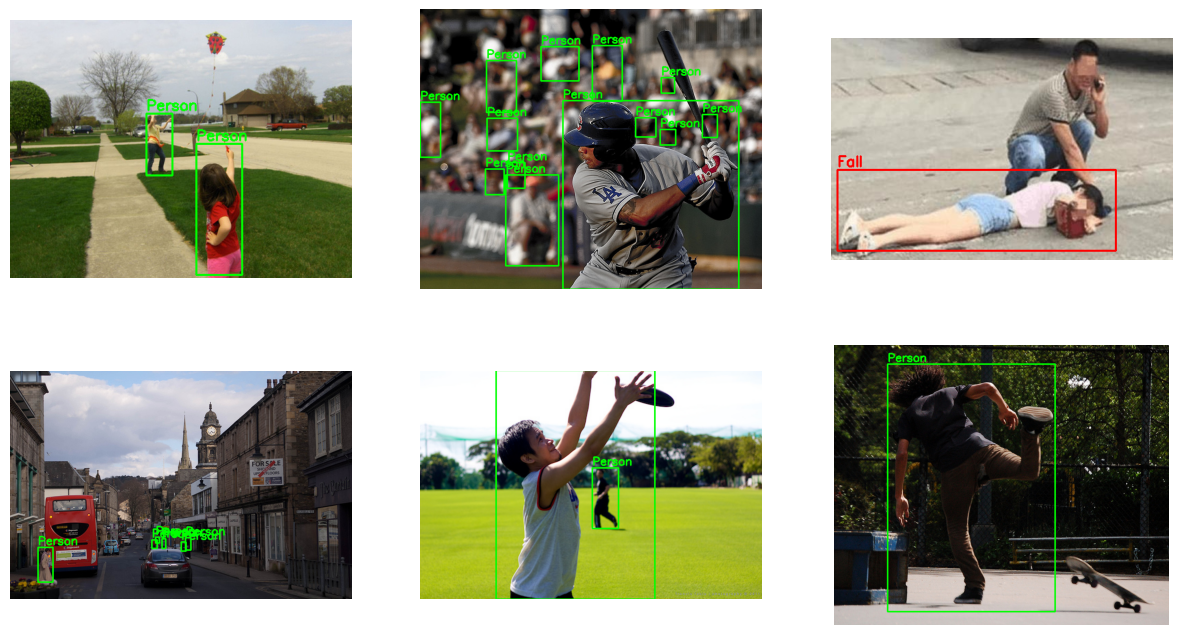

In [58]:
import random
import cv2
import matplotlib.pyplot as plt
from glob import glob
import os

imgs = glob("/content/Merged_Dataset/train/images/*")

samples = random.sample(imgs, 6)

plt.figure(figsize=(15,8))

for i,img_path in enumerate(samples):

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h,w = img.shape[:2]

    label = img_path.replace("/images/","/labels/")
    label = os.path.splitext(label)[0]+".txt"

    if os.path.exists(label):
        with open(label) as f:
            for line in f:
                cls,xc,yc,bw,bh = map(float,line.split())

                x1=int((xc-bw/2)*w)
                y1=int((yc-bh/2)*h)
                x2=int((xc+bw/2)*w)
                y2=int((yc+bh/2)*h)

                color=(255,0,0) if int(cls)==0 else (0,255,0)
                name="Fall" if int(cls)==0 else "Person"

                cv2.rectangle(img,(x1,y1),(x2,y2),color,2)
                cv2.putText(img,name,(x1,y1-5),
                            cv2.FONT_HERSHEY_SIMPLEX,
                            0.7,color,2)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.show()

In [59]:
for split in ["train","valid","test"]:
    print(split)
    print(len(glob(f"/content/Merged_Dataset/{split}/images/*")))
    print(len(glob(f"/content/Merged_Dataset/{split}/labels/*.txt")))

train
6648
6648
valid
1899
1899
test
950
950


In [60]:
from glob import glob
from collections import Counter

counter = Counter()

for txt in glob("/content/Merged_Dataset/train/labels/*.txt"):
    with open(txt) as f:
        for line in f:
            cls = int(line.split()[0])
            counter[cls] += 1

print(counter)

Counter({1: 14320, 0: 3149})


In [64]:
with open("/content/Merged_Dataset/data.yaml", "r") as f:
    data = yaml.safe_load(f)
    for i, name in enumerate(data["names"]):
      print(f"{i} --> {name}")

0 --> Fall-Detected
1 --> Person


In [65]:
model = YOLO("yolo11s.pt")

In [ ]:
results = model.train(

    data="/content/Merged_Dataset/data.yaml",

    # Training
    epochs=60,
    imgsz=640,
    batch=16,

    # Optimizer
    optimizer="AdamW",
    lr0=0.001,
    lrf=0.01,
    weight_decay=0.0005,

    # Scheduler
    warmup_epochs=5,
    patience=15,
    cos_lr=True,

    # Performance
    pretrained=True,
    amp=True,
    workers=4,
    device=0,

    # Save
    project="/content/drive/MyDrive/Hemaya",
    name="Fall_Detection_Merged",
    exist_ok=False,

    save=True,
    plots=True,
    save_period=1
)

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/Merged_Dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=Fall_Detection_Merged-3, nb